# Data Import and Function Definitions

## Import and process technology cost data

In [1]:
# @title Importing Libraries

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pypsa
# Only use the following for working in Google Colab
# from google.colab import files

In [2]:
# -----------------------------
# Settings
# -----------------------------
country = "DNK"
tech_year = 2025

# -----------------------------
# 1. Import technology costs like course notebook
# -----------------------------
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{tech_year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

ann = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]
costs["capital_cost"] = (ann + costs["FOM"] / 100) * costs["investment"]

techs = costs.loc[["solar", "onwind", "offwind", "OCGT"], ["capital_cost", "marginal_cost", "efficiency", "lifetime"]]
display(techs)

parameter,capital_cost,marginal_cost,efficiency,lifetime
technology,,,,
solar,63114.923985,0.010600,1.000,37.5
onwind,107441.457021,1.508000,1.000,28.5
offwind,184567.393550,0.021200,1.000,30.0
OCGT,48739.697513,65.423728,0.405,25.0


### Importing data

In [3]:
# Only use the following for working in Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# @title Importing capacity

df = pd.read_csv(r"GenerationProdTypeExchange.csv", sep=";", decimal=",", low_memory=False)
# Only use the following when working with Google Colab
# df = pd.read_csv(r"/content/drive/MyDrive/Dokumendid/KOOL/DTU/Integrated Energy Grids/GenerationProdTypeExchange.csv", sep=";", decimal=",", low_memory=False)

df["TimeDK"] = pd.to_datetime(df["TimeDK"])
df = df.set_index("TimeDK")

cols = ["GrossCon","OffshoreWindPower","OnshoreWindPower","SolarPower"]
df_sorted = df[cols]
df_sorted = df_sorted.groupby(df.index.floor("h")).sum()

df_cap = df_sorted["SolarPower"].max()

cf = pd.DataFrame({
    "solar": df_sorted["SolarPower"]/ df_sorted["SolarPower"].max(),
    "onwind": df_sorted["OnshoreWindPower"] / df_sorted["OnshoreWindPower"].max(),
    "offwind": df_sorted["OffshoreWindPower"] / df_sorted["OffshoreWindPower"].max(),
    "demand": df_sorted["GrossCon"],
}).fillna(0.0)


## Plotting Function Definitions

In [5]:
# @title Setting colours
colors = {
    "solar": "orange",
    "onwind": "green",
    "offwind": "blue",
    "OCGT": "firebrick",
    "battery": "limegreen",
    "H-turbine": "skyblue",
    "demand": "black"
}

In [6]:
winter_week_start = f"{tech_year}-01-01 00:00"
winter_week_end = f"{tech_year}-01-07 23:00"

summer_week_start = f"{tech_year}-07-01 00:00"
summer_week_end = f"{tech_year}-07-07 23:00"

In [7]:
# @title Extracting demand for summer and winter

demand_series = cf.demand.copy()
demand_series_winter = demand_series.loc[winter_week_start:winter_week_end]
demand_series_summer = demand_series.loc[summer_week_start:summer_week_end]

In [8]:
# @title Dispatch plotting Fn

def plot_dispatch(dispatch_df, demand_series):
    fig, ax = plt.subplots(figsize=(14, 5))

    dispatch_df.plot.area(ax=ax, color=[colors.get(col, "gray") for col in dispatch_df.columns])
    demand_series.plot(ax=ax, color=colors.get("demand", "black"), linewidth=1.5, label="demand")

    ax.set_ylabel("Dispatched Power [MW]", size=10)
    ax.set_xlabel("Day in a Month", size=10)
    ax.set_title(f"Dispatch {dispatch_df.index.min()} until {dispatch_df.index.max()}", size=15)
    ax.legend(loc="upper left", ncol=2)

    # plt.tight_layout()
    plt.show()

In [9]:
# @title Annual mix plotting Fn

def plot_electricity_mix(annual_dispatch_df):
  fig, ax = plt.subplots(figsize=(8, 4))

  annual_generation = (annual_dispatch_df.sum() / 1000).round(2)
  annual_generation.plot(kind="bar", ax=ax, color=[colors.get(idx, "gray") for idx in annual_generation.index])

  ax.set_ylabel("Energy dispatch [GWh]", size=10)
  ax.set_xlabel("Generator")
  ax.set_title(f"Annual electricity mix ({year})", size=15)

  plt.tight_layout()
  plt.show()

In [10]:
# @title State of Charge plot Fn

def plot_SoC(soc_series, time_unit):
    fig, ax = plt.subplots(figsize=(14, 5))

    soc_series.plot(figsize=(12,4), title="Battery State of Charge (%)", color=colors.get("battery"))

    ax.set_xlabel(f"Time [{time_unit}]")
    ax.set_ylabel("%")
    ax.set_title(f"SoC between {soc_series.index.min()} until {soc_series.index.max()}", size=15)
    ax.legend(loc="upper left", ncol=2)

    plt.tight_layout()
    plt.show()

# 1st Model Building (Generators and Demand)

In [11]:
#years = [2025] # use if only for 1 year
years = cf.index.year.unique()
print(years)
results = {}

for year in years:
    print(f"For year {year}")



    cf_year = cf[cf.index.year == year].copy()

    cf_year["solar"] /= cf_year["solar"].max()
    cf_year["onwind"] /= cf_year["onwind"].max()
    cf_year["offwind"] /= cf_year["offwind"].max()


    n = pypsa.Network()
    n.set_snapshots(cf_year.index)

    for carrier in ["electricity", "solar", "onwind", "offwind", "gas", "load_shedding"]:
        n.add("Carrier", carrier)


    n.add("Bus", "electricity", carrier="electricity")
    n.add("Load", "demand", bus="electricity", p_set=cf_year["demand"])

    n.add(
        "Generator",
        "solar",
        bus="electricity",
        carrier="solar",
        p_nom_extendable=True,
        p_max_pu=cf_year["solar"],
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
    )

    n.add(
        "Generator",
        "onwind",
        bus="electricity",
        carrier="onwind",
        p_nom_extendable=True,
        p_max_pu=cf_year["onwind"],
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
    )

    n.add(
        "Generator",
        "offwind",
        bus="electricity",
        carrier="offwind",
        p_nom_extendable=True,
        p_max_pu=cf_year["offwind"],
        capital_cost=costs.at["offwind", "capital_cost"],
        marginal_cost=costs.at["offwind", "marginal_cost"],
    )

    n.add(
        "Generator",
        "OCGT",
        bus="electricity",
        carrier="gas",
        p_nom_extendable=True,
        capital_cost=costs.at["OCGT", "capital_cost"],
        marginal_cost=costs.at["OCGT", "marginal_cost"],
    )

    n.add(
        "Generator",
        "load_shedding",
        bus="electricity",
        carrier="load_shedding",
        p_nom=float(cf_year["demand"].max()),
        marginal_cost=10_000,
    )

Index([2020, 2021, 2022, 2023, 2024, 2025], dtype='int32', name='TimeDK')
For year 2020
For year 2021
For year 2022
For year 2023
For year 2024
For year 2025


# 1st Model Optimisation

In [12]:
n.optimize(solver_name="highs")

results[year] = n

C:\Users\mammu\AppData\Local\Temp\ipykernel_1248\978073392.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="highs")
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 162.56it/s]
INFO:linopy.io: Writing time: 0.18s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43799 primals, 96353 duals
Objective: 2.50e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


## 1st Model Data Preparation

In [13]:
# @title Preparing data for plotting

dispatch = n.generators_t.p.copy()

# Exclude load shedding
dispatch_plot = dispatch.drop(columns="load_shedding", errors="ignore")

# Annual generation in GWh
annual_generation = (dispatch_plot.sum() / 1000).round(2)

# Capacity factors
capacities = n.generators["p_nom_opt"].drop("load_shedding", errors="ignore")
capacity_factors = (
    dispatch_plot.sum() / (capacities * len(n.snapshots))
).fillna(0).round(3)

# Defining summer and winter dispatches
summer = dispatch_plot.loc[summer_week_start:summer_week_end]
winter = dispatch_plot.loc[winter_week_start:winter_week_end]

## 1st Model Results

In [14]:
# @title Numerical results
print("Optimal capacities (MW)")
display(capacities.round(2))

print("\nAnnual generation (GWh)")
display(annual_generation)

print("\nCapacity factors")
display(capacity_factors)

Optimal capacities (MW)


name
solar      3463.75
onwind     7529.51
offwind      -0.00
OCGT       5685.41
Name: p_nom_opt, dtype: float64


Annual generation (GWh)


name
solar       4078.45
onwind     17540.18
offwind        0.00
OCGT       17847.65
dtype: float64


Capacity factors


name
solar      0.134
onwind     0.266
offwind    0.000
OCGT       0.358
dtype: float64

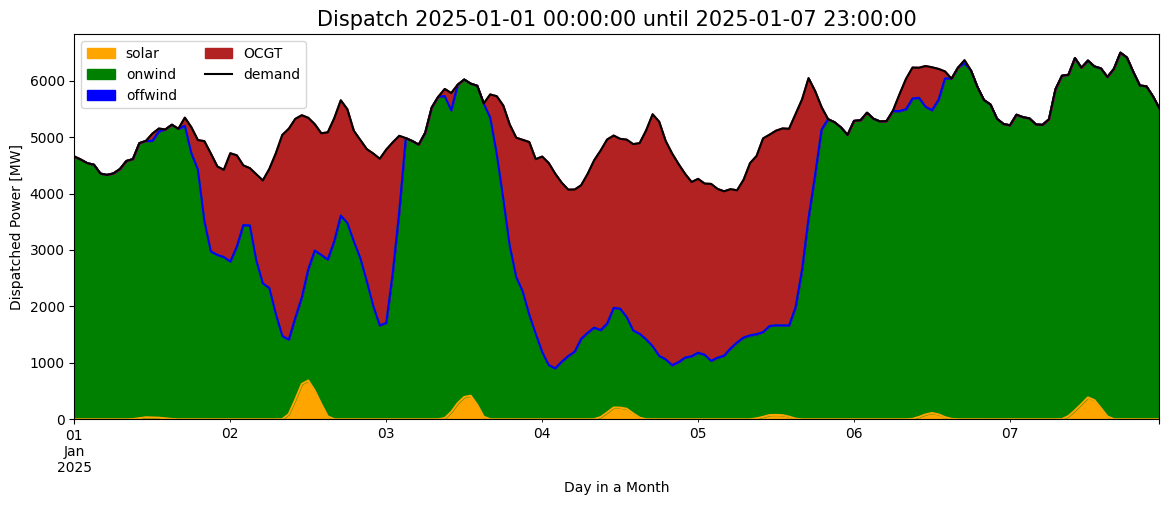

In [15]:
# @title Winter week dispatch

plot_dispatch(winter, demand_series.loc[winter.index])

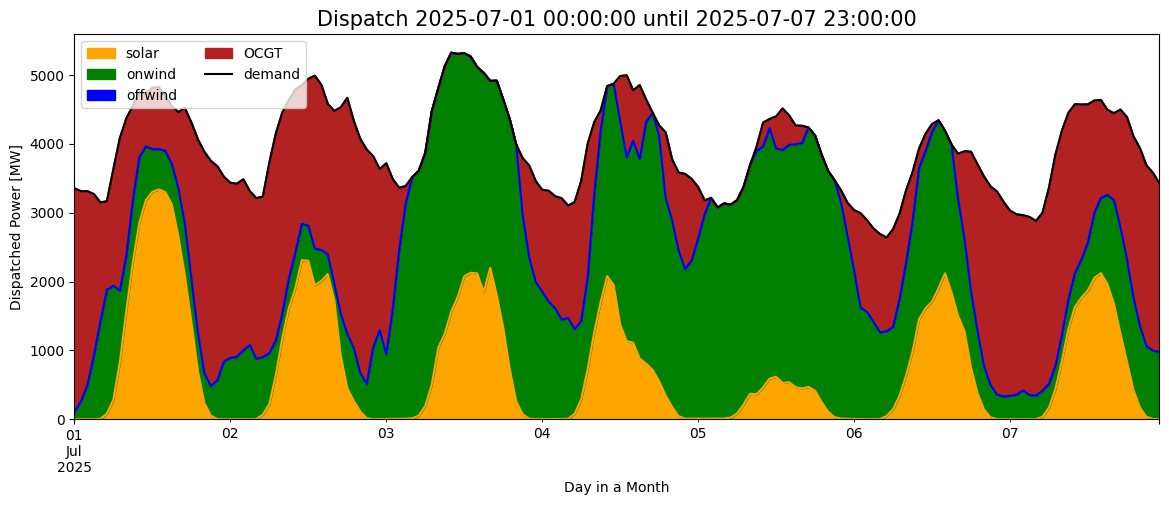

In [16]:
# @title Summer week dispatch

plot_dispatch(summer, demand_series.loc[summer.index])

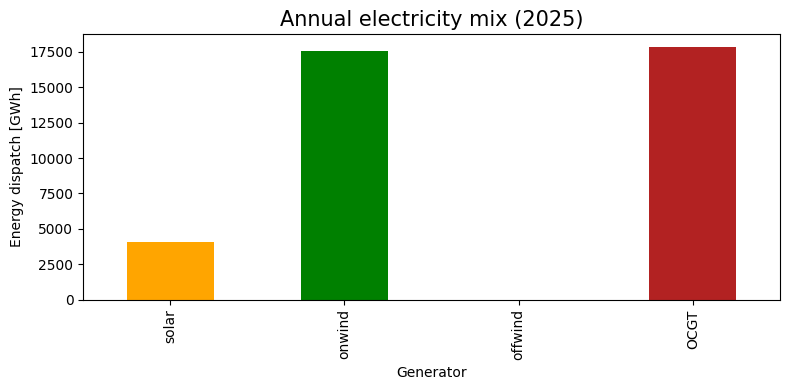

In [17]:
# @title Annual electricity mix

plot_electricity_mix(dispatch_plot)

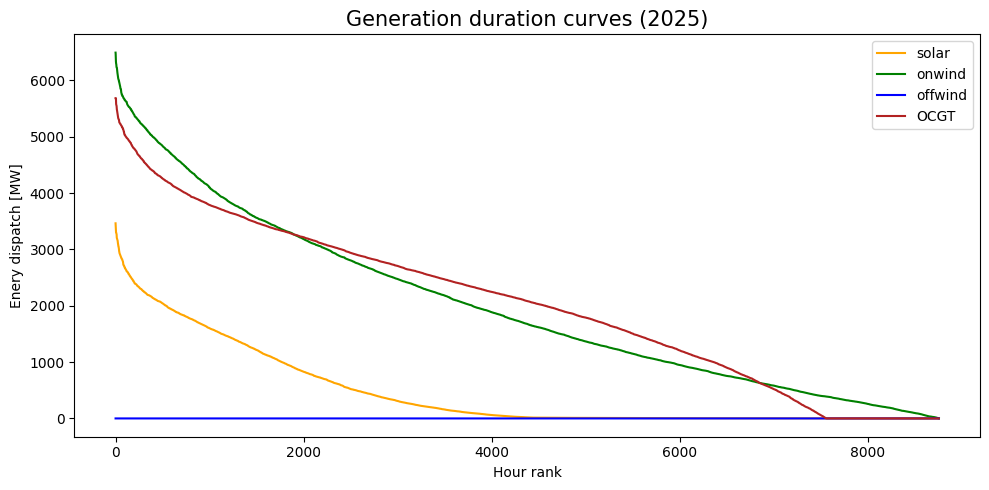

In [18]:
# @title Duration curve

fig, ax = plt.subplots(figsize=(10, 5))
for col in dispatch_plot.columns:
    dispatch_plot[col].sort_values(ascending=False).reset_index(drop=True).plot(ax=ax, label=col, color=colors.get(col, "gray"))

ax.set_xlabel("Hour rank", size=10)
ax.set_ylabel("Enery dispatch [MW]", size=10)
ax.set_title(f"Generation duration curves ({tech_year})", size=15)
ax.legend()
plt.tight_layout()
plt.show()

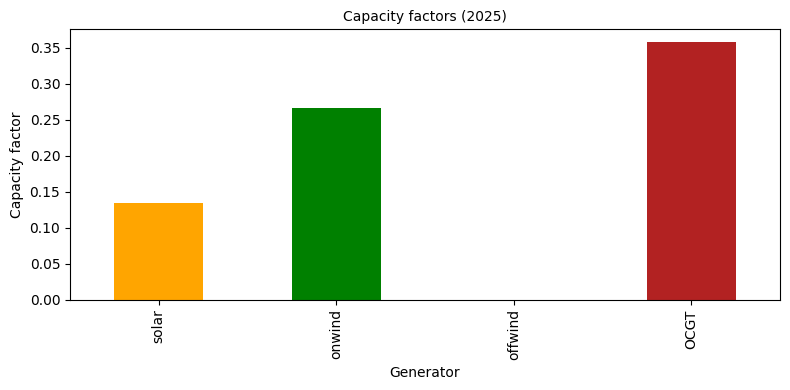

In [19]:
# @title Capacity factor chart

fig, ax = plt.subplots(figsize=(8, 4))
capacity_factors.plot(kind="bar", ax=ax, color=[colors.get(idx, "gray") for idx in capacity_factors.index])
ax.set_ylabel("Capacity factor", size=10)
ax.set_xlabel("Generator", size=10)
ax.set_title(f"Capacity factors ({tech_year})", size=10)
plt.tight_layout()
plt.show()

# 2nd Model Building (Storage Added)

In [20]:
# @title Adding battery storage components

# Rebuild a fresh network object for model 2 to avoid state carried from model 1 optimization.
cf_year_2 = cf[cf.index.year == tech_year].copy()
cf_year_2["solar"] /= cf_year_2["solar"].max()
cf_year_2["onwind"] /= cf_year_2["onwind"].max()
cf_year_2["offwind"] /= cf_year_2["offwind"].max()

n2 = pypsa.Network()
n2.set_snapshots(cf_year_2.index)

for carrier in ["electricity", "solar", "onwind", "offwind", "gas", "load_shedding", "hydrogen"]:
    n2.add("Carrier", carrier)

n2.add("Bus", "electricity", carrier="electricity")
n2.add("Load", "demand", bus="electricity", p_set=cf_year_2["demand"])

n2.add(
    "Generator",
    "solar",
    bus="electricity",
    carrier="solar",
    p_nom_extendable=True,
    p_max_pu=cf_year_2["solar"],
    capital_cost=costs.at["solar", "capital_cost"],
    marginal_cost=costs.at["solar", "marginal_cost"],
)

n2.add(
    "Generator",
    "onwind",
    bus="electricity",
    carrier="onwind",
    p_nom_extendable=True,
    p_max_pu=cf_year_2["onwind"],
    capital_cost=costs.at["onwind", "capital_cost"],
    marginal_cost=costs.at["onwind", "marginal_cost"],
)

n2.add(
    "Generator",
    "offwind",
    bus="electricity",
    carrier="offwind",
    p_nom_extendable=True,
    p_max_pu=cf_year_2["offwind"],
    capital_cost=costs.at["offwind", "capital_cost"],
    marginal_cost=costs.at["offwind", "marginal_cost"],
)

n2.add(
    "Generator",
    "OCGT",
    bus="electricity",
    carrier="gas",
    p_nom_extendable=True,
    capital_cost=costs.at["OCGT", "capital_cost"],
    marginal_cost=costs.at["OCGT", "marginal_cost"],
)

n2.add(
    "Generator",
    "load_shedding",
    bus="electricity",
    carrier="load_shedding",
    p_nom=float(cf_year_2["demand"].max()),
    marginal_cost=10_000,
)

n2.add("StorageUnit",
      "battery",
      bus="electricity",
      p_nom_extendable=True,

      max_hours=4,  # energy = 4h * power
      # might be due to change. Depends on the realistic scale and needs. Can be separated to energy and power.

      #capital_cost=400,  # EUR/kW (power cost)
      capital_cost=(costs.at["Lithium-Ion-NMC-bicharger", "capital_cost"] + costs.at["Lithium-Ion-NMC-store", "capital_cost"]),
      marginal_cost=costs.at["Lithium-Ion-NMC-bicharger", "marginal_cost"],

      efficiency_store=0.95,
      efficiency_dispatch=0.95,

      cyclic_state_of_charge=True,
      overwrite=True)

In [21]:
# @title Adding H-bus and H components

n2.add("Bus", "hydrogen", carrier="hydrogen", overwrite=True)

n2.add("Link",
      "electrolyser",
      bus0="electricity",
      bus1="hydrogen",

      p_nom_extendable=True,
      efficiency=0.70,

      p_min_pu = 0, # Min power flow is 0 and not negative:
      # we want to restrict H energy being converted into electrical energy here
      # as the electrolizer is monodirectional energy converter.

      capital_cost=costs.at["PEM electrolyzer", "capital_cost"],
      overwrite=True)

n2.add("Store",
      "hydrogen_storage",
      bus="hydrogen",

      e_nom_extendable=True,
      capital_cost=costs.at["hydrogen storage underground", "capital_cost"],

      e_cyclic=True,
      overwrite=True)

n2.add("Link",
      "hydrogen_turbine",
      bus0="hydrogen",
      bus1="electricity",

      p_nom_extendable=True,
      efficiency=0.50,

      p_min_pu = 0, # Min power flow is 0 and not negative:
      # we want to restrict electrical energy being converted into H here
      # as the gas turbine is monodirectional energy converter.

      capital_cost=costs.at["fuel cell", "capital_cost"],
      overwrite=True)

# 2nd Model Optimisation

In [22]:
n2.optimize(solver_name="highs")

C:\Users\mammu\AppData\Local\Temp\ipykernel_1248\315756.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n2.optimize(solver_name="highs")
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 225.41it/s]
INFO:linopy.io: Writing time: 0.32s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 105116 primals, 227742 duals
Objective: 2.49e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, S

('ok', 'optimal')

## 2nd Model Results Preparation

In [23]:
# @title Extracting different dispatches

# Exclude load shedding
dispatch = n2.generators_t.p.drop(columns="load_shedding", errors="ignore").copy()
battery_dispatch = n2.storage_units_t.p_dispatch["battery"].copy()
H_dispatch = -n2.links_t.p1["hydrogen_turbine"].copy()

# Exclude load shedding
dispatch_clean = dispatch.drop(columns="load_shedding", errors="ignore")

In [24]:
# @title Calculating common dispatch

# Adding battery and H turbine to the dispatch
common_dispatch = dispatch.copy()
common_dispatch["battery"] = battery_dispatch.round().abs()
common_dispatch["H-turbine"] = H_dispatch

# Creating summer and winter dataframes
common_dispatch_winter = common_dispatch.loc[winter_week_start:winter_week_end]
common_dispatch_summer = common_dispatch.loc[summer_week_start:summer_week_end]

In [25]:
# @title Calculating state of charge [%]

soc = n2.storage_units_t.state_of_charge["battery"]
e_nom = n2.storage_units.p_nom_opt["battery"] * n2.storage_units.max_hours["battery"]

soc_percent = 100 * soc / e_nom

In [26]:
# @title Calcualting annual generation

annual_generation = (common_dispatch.sum() / 1000).round(2)

In [27]:
# @title Calculating capacities and capacity factors

gen_capacities = n2.generators["p_nom_opt"].drop("load_shedding", errors="ignore")

storage_capacities = n2.storage_units["p_nom_opt"]

common_capacities = gen_capacities.copy()
common_capacities["battery"] = storage_capacities["battery"]

capacity_factors = (
    common_dispatch.sum() / (common_capacities * len(n2.snapshots))
).fillna(0).round(3)

## 2nd Model Results Plotting

In [28]:
# @title Numerical Values

print("Optimal capacities (MW)")
display(common_capacities.round(2))

print("\nAnnual generation (GWh)")
display(annual_generation)

print("\nCapacity factors")
display(capacity_factors)

Optimal capacities (MW)


name
solar      4106.10
onwind     7493.52
offwind      -0.00
OCGT       5250.06
battery     479.09
Name: p_nom_opt, dtype: float64


Annual generation (GWh)


name
solar         4834.80
onwind       17524.61
offwind          0.00
OCGT         17127.24
battery        186.86
H-turbine        0.00
dtype: float64


Capacity factors


name
H-turbine    0.000
OCGT         0.372
battery      0.045
offwind      0.000
onwind       0.267
solar        0.134
dtype: float64

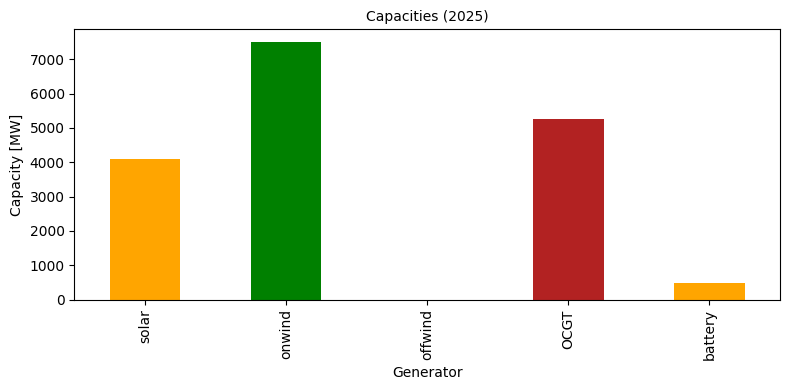

In [29]:
# @title Capacities visualisation
fig, ax = plt.subplots(figsize=(8, 4))

common_capacities.plot(kind="bar", ax=ax, color=[colors.get(idx, "gray") for idx in gen_capacities.index])
#storage_capacities.plot(kind="bar", ax=ax, color=[colors.get(idx, "gray") for idx in storage_capacities.index])

ax.set_ylabel("Capacity [MW]", size=10)
ax.set_xlabel("Generator", size=10)
ax.set_title(f"Capacities ({tech_year})", size=10)
plt.tight_layout()
plt.show()

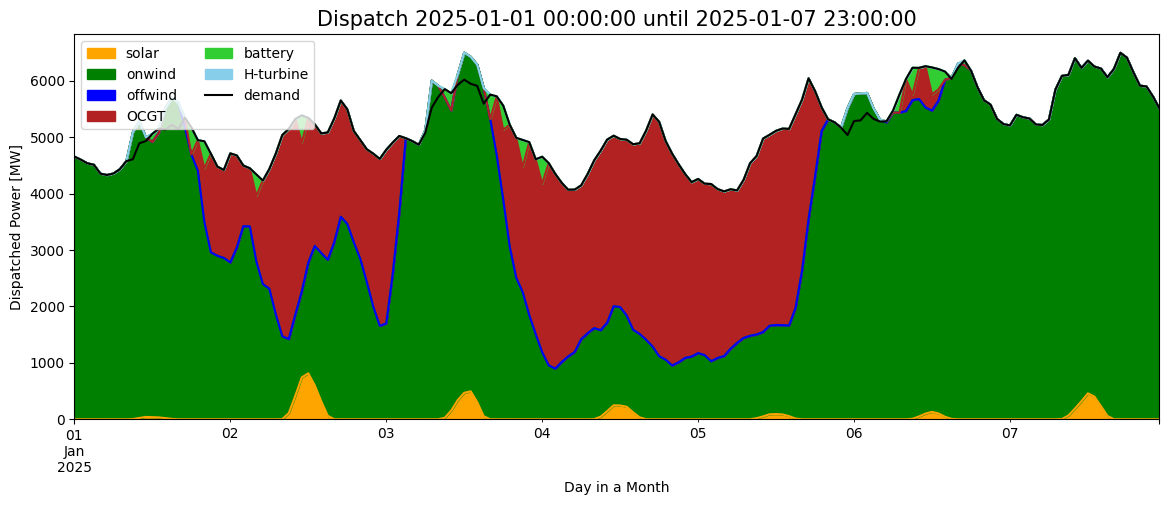

In [30]:
# @title Winter week dispatches
plot_dispatch(common_dispatch_winter, demand_series_winter)

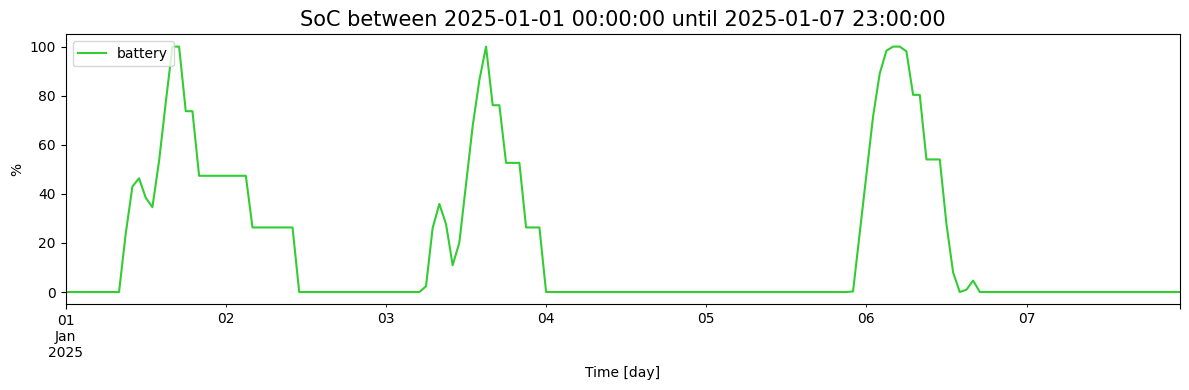

In [31]:
# @title Winter week SoC
plot_SoC(soc_percent.loc[winter_week_start:winter_week_end], "day")

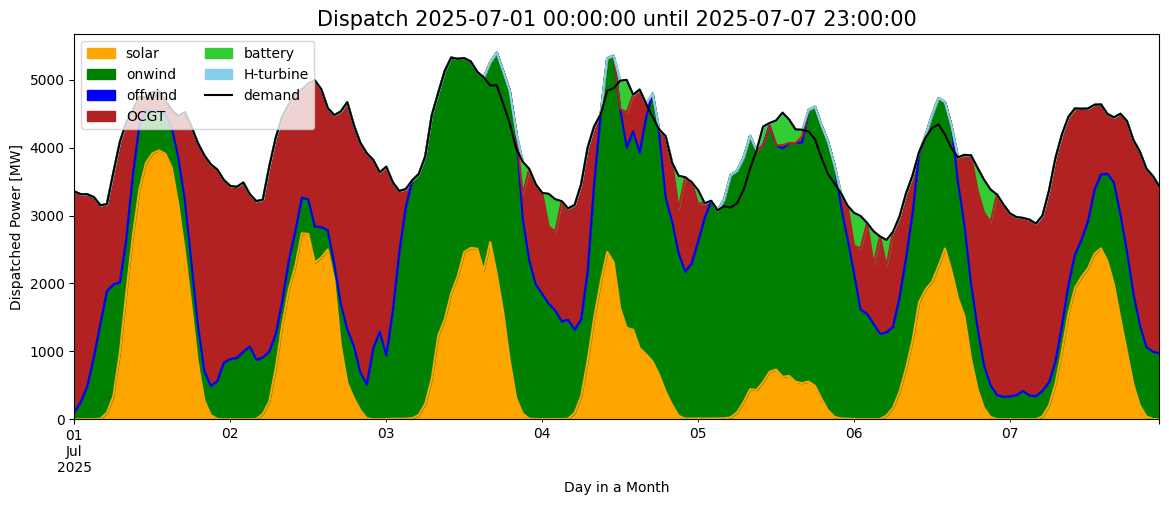

In [32]:
# @title Summer week dispatches
plot_dispatch(common_dispatch_summer, demand_series_summer)

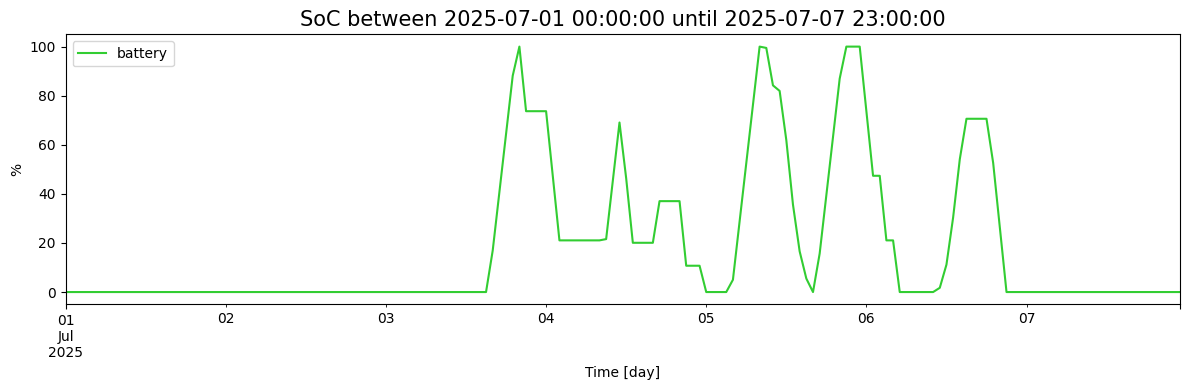

In [33]:
# @title Summer week SoC
plot_SoC(soc_percent.loc[summer_week_start:summer_week_end], "day")

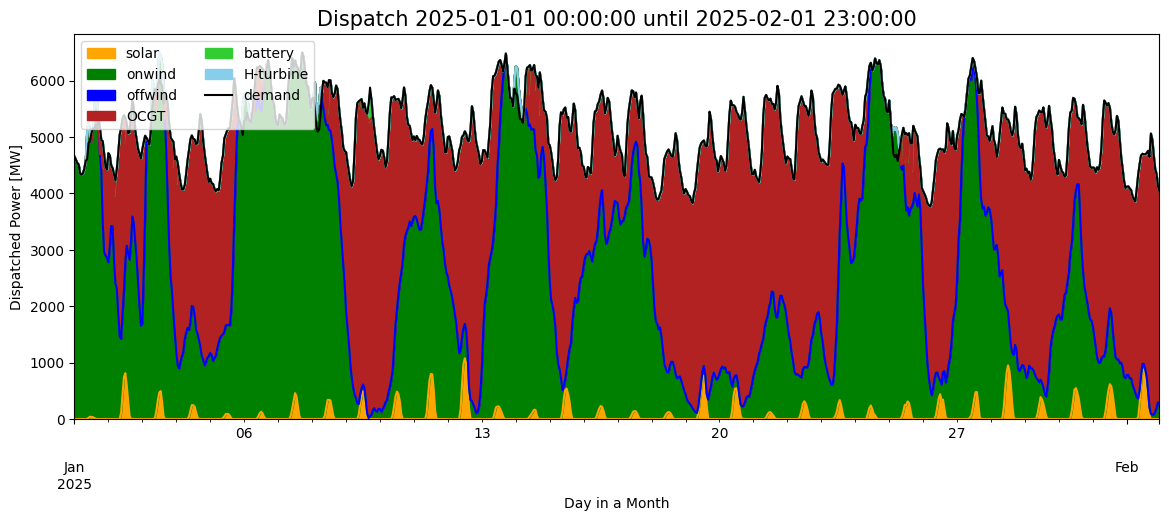

In [34]:
# @title Common Disptach - January
month_start = f"{tech_year}-01-01"
month_end = f"{tech_year}-02-01"

plot_dispatch(common_dispatch.loc[month_start:month_end], demand_series.loc[month_start:month_end])

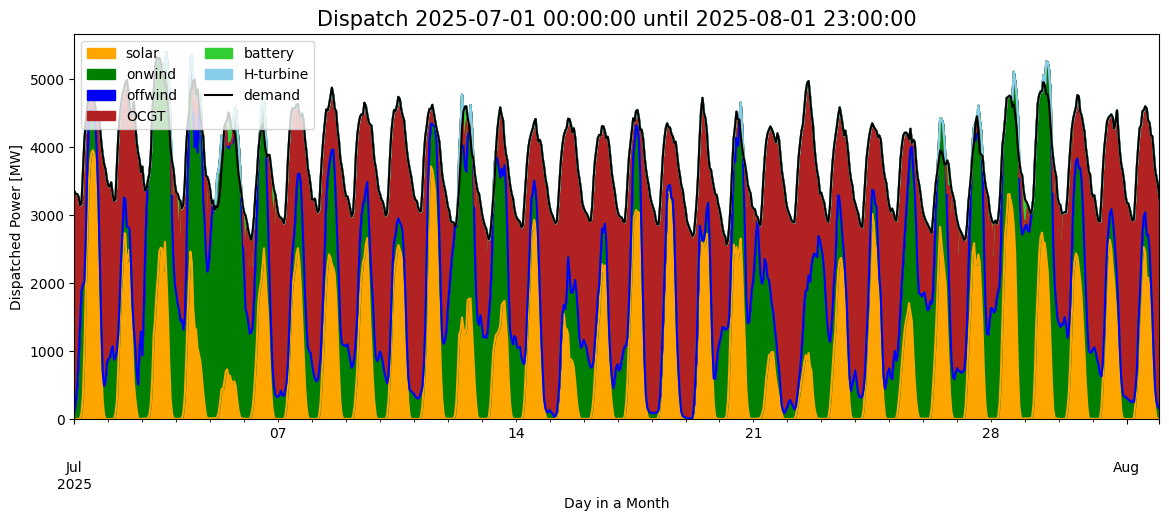

In [35]:
# @title Common Disptach - June
month_start = f"{tech_year}-07-01"
month_end = f"{tech_year}-08-01"

plot_dispatch(common_dispatch.loc[month_start:month_end], demand_series.loc[month_start:month_end])

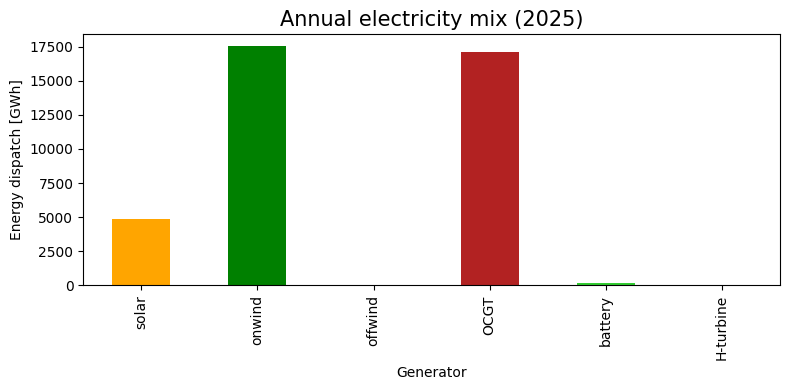

In [36]:
# @title New annual electricity mix

plot_electricity_mix(common_dispatch)

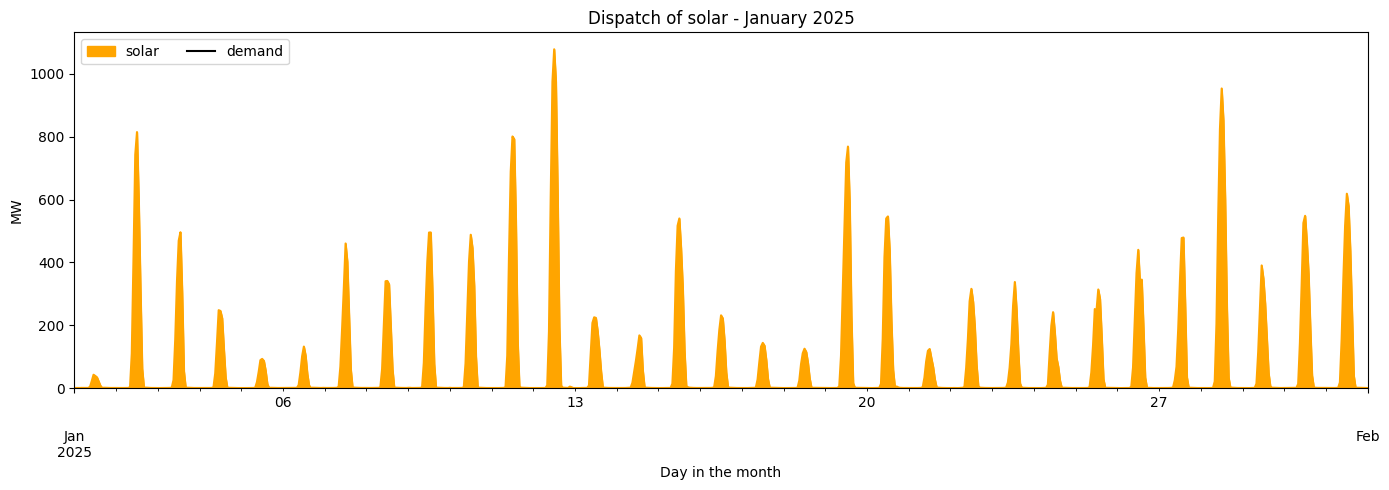

In [37]:
# @title Single resource dispatch (not used)

jan_month_start = f"{tech_year}-01-01 00:00"
jan_month_end = f"{tech_year}-02-01 00:00"

resource = "solar"

def plot_single_dispatch(dispatch_df, resource):
    fig, ax = plt.subplots(figsize=(14, 5))
    dispatch_df[resource].loc[jan_month_start:jan_month_end].plot.area(
        ax=ax,
        color=colors.get(resource),
    )
    demand_series.loc[jan_month_start:jan_month_end].plot(
        ax=ax,
        color=colors.get("demand"),
        linewidth=1.5,
        label="demand",
    )

    ax.set_ylabel("MW")
    ax.set_title(f"Dispatch of {resource} - January {tech_year}")
    ax.set_xlabel("Day in the month")
    ax.legend(loc="upper left", ncol=2)

    plt.tight_layout()
    plt.show()

plot_single_dispatch(common_dispatch, resource)

In [38]:
dispatch = n2.generators_t.p.copy()

# Exclude load shedding
dispatch_plot = dispatch.drop(columns="load_shedding", errors="ignore")

# Annual generation in GWh
annual_generation = (dispatch_plot.sum() / 1000).round(2)

# Capacity factors
capacities = n2.generators["p_nom_opt"].drop("load_shedding", errors="ignore")
capacity_factors = (
    dispatch_plot.sum() / (capacities * len(n2.snapshots))
).fillna(0).round(3)

# 3rd Model
### Data import and handling

In [39]:
#Data import and handling (OPSD only, 2019)

task_d_year = 2019

opsd = pd.read_csv("time_series_60min_singleindex.csv")
opsd["utc_timestamp"] = pd.to_datetime(opsd["utc_timestamp"], utc=True)
opsd = opsd.set_index("utc_timestamp")

opsd_y = opsd[opsd.index.year == task_d_year].copy()

# Hourly demand
demand = pd.DataFrame(index=opsd_y.index)

demand["DK1"] = opsd_y["DK_1_load_actual_entsoe_transparency"].fillna(0.0)
demand["DK2"] = opsd_y["DK_2_load_actual_entsoe_transparency"].fillna(0.0)
demand["DE"]  = opsd_y["DE_load_actual_entsoe_transparency"].fillna(0.0)
demand["SE"]  = opsd_y["SE_load_actual_entsoe_transparency"].fillna(0.0)
demand["NO"]  = opsd_y["NO_load_actual_entsoe_transparency"].fillna(0.0)

# Renewable availability factors
# generation / yearly max generation
cf_d = pd.DataFrame(index=opsd_y.index)

for area in ["DK1", "DK2"]:
    prefix = "DK_1" if area == "DK1" else "DK_2"

    cf_d[f"{area}_solar"] = (
        opsd_y[f"{prefix}_solar_generation_actual"]
        / opsd_y[f"{prefix}_solar_generation_actual"].max()
    ).fillna(0.0)

    cf_d[f"{area}_onwind"] = (
        opsd_y[f"{prefix}_wind_onshore_generation_actual"]
        / opsd_y[f"{prefix}_wind_onshore_generation_actual"].max()
    ).fillna(0.0)

    cf_d[f"{area}_offwind"] = (
        opsd_y[f"{prefix}_wind_offshore_generation_actual"]
        / opsd_y[f"{prefix}_wind_offshore_generation_actual"].max()
    ).fillna(0.0)

# Fixed neighbour capacities [MW]
# Use OPSD capacities where available
def last_valid(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return float(s.iloc[-1]) if len(s) > 0 else 0.0

neighbor_caps = pd.DataFrame(index=["DE", "SE", "NO"], columns=["solar", "onwind", "offwind", "ocgt"], dtype=float)

# Germany: capacities exist directly in OPSD
neighbor_caps.loc["DE", "solar"]   = last_valid(opsd_y["DE_solar_capacity"])
neighbor_caps.loc["DE", "onwind"]  = last_valid(opsd_y["DE_wind_onshore_capacity"])
neighbor_caps.loc["DE", "offwind"] = last_valid(opsd_y["DE_wind_offshore_capacity"])

# Sweden: only onshore/offshore wind capacities exist, but we only have onshore generation
neighbor_caps.loc["SE", "solar"]   = 0.0
neighbor_caps.loc["SE", "onwind"]  = last_valid(opsd_y["SE_wind_onshore_capacity"])
neighbor_caps.loc["SE", "offwind"] = 0.0

# Norway: no clean OPSD capacity column in this file, so use max observed generation as proxy
neighbor_caps.loc["NO", "solar"]   = 0.0
neighbor_caps.loc["NO", "onwind"]  = opsd_y["NO_wind_onshore_generation_actual"].max()
neighbor_caps.loc["NO", "offwind"] = 0.0


# Neighbour renewable availability factors

# Germany: use OPSD profile columns directly
cf_d["DE_solar"]   = pd.to_numeric(opsd_y["DE_solar_profile"], errors="coerce").fillna(0.0).clip(lower=0.0, upper=1.0)
cf_d["DE_onwind"]  = pd.to_numeric(opsd_y["DE_wind_onshore_profile"], errors="coerce").fillna(0.0).clip(lower=0.0, upper=1.0)
cf_d["DE_offwind"] = pd.to_numeric(opsd_y["DE_wind_offshore_profile"], errors="coerce").fillna(0.0).clip(lower=0.0, upper=1.0)

# Sweden: use actual generation / installed capacity
cf_d["SE_solar"] = 0.0
cf_d["SE_onwind"] = (
    opsd_y["SE_wind_onshore_generation_actual"] / neighbor_caps.loc["SE", "onwind"]
).replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0.0, upper=1.0)
cf_d["SE_offwind"] = 0.0

# Norway: use actual generation / proxy capacity
cf_d["NO_solar"] = 0.0
cf_d["NO_onwind"] = (
    opsd_y["NO_wind_onshore_generation_actual"] / neighbor_caps.loc["NO", "onwind"]
).replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0.0, upper=1.0)
cf_d["NO_offwind"] = 0.0

cf_d = cf_d.fillna(0.0)

# Fixed neighbour OCGT capacities [MW]
actual_gen = pd.DataFrame(index=opsd_y.index)

actual_gen["DE_solar"]   = opsd_y["DE_solar_generation_actual"].fillna(0.0)
actual_gen["DE_onwind"]  = opsd_y["DE_wind_onshore_generation_actual"].fillna(0.0)
actual_gen["DE_offwind"] = opsd_y["DE_wind_offshore_generation_actual"].fillna(0.0)

actual_gen["SE_solar"]   = 0.0
actual_gen["SE_onwind"]  = opsd_y["SE_wind_onshore_generation_actual"].fillna(0.0)
actual_gen["SE_offwind"] = 0.0

actual_gen["NO_solar"]   = 0.0
actual_gen["NO_onwind"]  = opsd_y["NO_wind_onshore_generation_actual"].fillna(0.0)
actual_gen["NO_offwind"] = 0.0

for area in ["DE", "SE", "NO"]:
    residual = (
        demand[area]
        - actual_gen[f"{area}_solar"]
        - actual_gen[f"{area}_onwind"]
        - actual_gen[f"{area}_offwind"]
    ).clip(lower=0.0)
    neighbor_caps.loc[area, "ocgt"] = residual.max()

neighbor_caps = neighbor_caps.fillna(0.0)


# Fixed line capacities [MW]
# Existing interconnector transfer capacities
line_data = pd.DataFrame([
    ["DK1", "DK2",  590],
    ["DK1", "DE", 2500],
    ["DK2", "DE",  585],
    ["DK2", "SE", 1300],
    ["DK1", "NO", 1632],
], columns=["bus0", "bus1", "s_nom"])

line_data["x"] = 0.1
line_data["v_nom"] = 400

print("Task d year:", task_d_year)
print("Snapshots:", len(opsd_y))
display(demand.head())
display(cf_d.head())
display(neighbor_caps.round(2))
display(line_data)

Task d year: 2019
Snapshots: 8760


,DK1,DK2,DE,SE,NO
utc_timestamp,,,,,
2019-01-01 00:00:00+00:00,1837.71,1348.33,41562.0,14375.0,15622.94
2019-01-01 01:00:00+00:00,1778.86,1291.21,40100.0,14153.0,15705.29
2019-01-01 02:00:00+00:00,1726.38,1239.81,38883.0,13896.0,15643.08
2019-01-01 03:00:00+00:00,1709.62,1223.86,38806.0,13955.0,15611.87
2019-01-01 04:00:00+00:00,1716.39,1224.25,38593.0,14166.0,15727.78


,DK1_solar,DK1_onwind,DK1_offwind,DK2_solar,DK2_onwind,DK2_offwind,DE_solar,DE_onwind,DE_offwind,SE_solar,SE_onwind,SE_offwind,NO_solar,NO_onwind,NO_offwind
utc_timestamp,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,0.0,0.726043,0.209534,0.0,0.898586,0.903388,0.0,0.5017,0.5678,0.0,0.595856,0.0,0.0,0.490911,0.0
2019-01-01 01:00:00+00:00,0.0,0.692453,0.090343,0.0,0.819642,0.720862,0.0,0.5179,0.4870,0.0,0.570469,0.0,0.0,0.498384,0.0
2019-01-01 02:00:00+00:00,0.0,0.685225,0.088387,0.0,0.794851,0.566904,0.0,0.5435,0.5341,0.0,0.561703,0.0,0.0,0.487684,0.0
2019-01-01 03:00:00+00:00,0.0,0.666757,0.086499,0.0,0.764962,0.552355,0.0,0.5902,0.5105,0.0,0.557263,0.0,0.0,0.463944,0.0
2019-01-01 04:00:00+00:00,0.0,0.645172,0.086212,0.0,0.758067,0.552222,0.0,0.6244,0.4710,0.0,0.557149,0.0,0.0,0.449288,0.0


,solar,onwind,offwind,ocgt
DE,50508.0,44710.00,5742.0,72655.00
SE,0.0,8784.00,0.0,24402.00
NO,0.0,1936.44,0.0,26934.46


,bus0,bus1,s_nom,x,v_nom
0,DK1,DK2,590,0.1,400
1,DK1,DE,2500,0.1,400
2,DK2,DE,585,0.1,400
3,DK2,SE,1300,0.1,400
4,DK1,NO,1632,0.1,400


In [40]:
# Building network

# PyPSA requires timezone-naive snapshots; align all related time series.
snapshots_3 = opsd_y.index.tz_localize(None)
demand_3 = demand.copy()
cf_d_3 = cf_d.copy()
demand_3.index = snapshots_3
cf_d_3.index = snapshots_3

n3 = pypsa.Network()
n3.set_snapshots(snapshots_3)

# -----------------------------
# Carriers
# -----------------------------
for carrier in ["AC", "solar", "onwind", "offwind", "gas", "load_shedding", "hydrogen"]:
    n3.add("Carrier", carrier)

# -----------------------------
# Buses
# -----------------------------
for bus in ["DK1", "DK2", "DE", "SE", "NO"]:
    n3.add("Bus", bus, carrier="AC", v_nom=400)

n3.add("Bus", "DK1_hydrogen", carrier="hydrogen")
n3.add("Bus", "DK2_hydrogen", carrier="hydrogen")

# -----------------------------
# Loads
# -----------------------------
for bus in ["DK1", "DK2", "DE", "SE", "NO"]:
    n3.add("Load", f"{bus}_demand", bus=bus, p_set=demand_3[bus])

# -----------------------------
# Danish extendable generators
# -----------------------------
for bus in ["DK1", "DK2"]:
    n3.add(
        "Generator",
        f"{bus}_solar",
        bus=bus,
        carrier="solar",
        p_nom_extendable=True,
        p_max_pu=cf_d_3[f"{bus}_solar"],
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
    )

    n3.add(
        "Generator",
        f"{bus}_onwind",
        bus=bus,
        carrier="onwind",
        p_nom_extendable=True,
        p_max_pu=cf_d_3[f"{bus}_onwind"],
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
    )

    n3.add(
        "Generator",
        f"{bus}_offwind",
        bus=bus,
        carrier="offwind",
        p_nom_extendable=True,
        p_max_pu=cf_d_3[f"{bus}_offwind"],
        capital_cost=costs.at["offwind", "capital_cost"],
        marginal_cost=costs.at["offwind", "marginal_cost"],
    )

    n3.add(
        "Generator",
        f"{bus}_OCGT",
        bus=bus,
        carrier="gas",
        p_nom_extendable=True,
        capital_cost=costs.at["OCGT", "capital_cost"],
        marginal_cost=costs.at["OCGT", "marginal_cost"],
    )

    n3.add(
        "Generator",
        f"{bus}_load_shedding",
        bus=bus,
        carrier="load_shedding",
        p_nom=float(demand_3[bus].max()),
        marginal_cost=10000,
    )

# -----------------------------
# Fixed neighbour generators
# -----------------------------
for bus in ["DE", "SE", "NO"]:
    n3.add(
        "Generator",
        f"{bus}_solar",
        bus=bus,
        carrier="solar",
        p_nom=neighbor_caps.loc[bus, "solar"],
        p_max_pu=cf_d_3[f"{bus}_solar"],
        marginal_cost=costs.at["solar", "marginal_cost"],
    )

    n3.add(
        "Generator",
        f"{bus}_onwind",
        bus=bus,
        carrier="onwind",
        p_nom=neighbor_caps.loc[bus, "onwind"],
        p_max_pu=cf_d_3[f"{bus}_onwind"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
    )

    n3.add(
        "Generator",
        f"{bus}_offwind",
        bus=bus,
        carrier="offwind",
        p_nom=neighbor_caps.loc[bus, "offwind"],
        p_max_pu=cf_d_3[f"{bus}_offwind"],
        marginal_cost=costs.at["offwind", "marginal_cost"],
    )

    n3.add(
        "Generator",
        f"{bus}_OCGT",
        bus=bus,
        carrier="gas",
        p_nom=neighbor_caps.loc[bus, "ocgt"],
        marginal_cost=costs.at["OCGT", "marginal_cost"],
    )

# -----------------------------
# Danish battery storage
# -----------------------------
for bus in ["DK1", "DK2"]:
    n3.add(
        "StorageUnit",
        f"{bus}_battery",
        bus=bus,
        p_nom_extendable=True,
        max_hours=4,
        capital_cost=(
            costs.at["Lithium-Ion-NMC-bicharger", "capital_cost"]
            + costs.at["Lithium-Ion-NMC-store", "capital_cost"]
        ),
        marginal_cost=costs.at["Lithium-Ion-NMC-bicharger", "marginal_cost"],
        efficiency_store=0.95,
        efficiency_dispatch=0.95,
        cyclic_state_of_charge=True,
    )


# Danish hydrogen components
for bus in ["DK1", "DK2"]:
    h2_bus = f"{bus}_hydrogen"

    n3.add(
        "Link",
        f"{bus}_electrolyser",
        bus0=bus,
        bus1=h2_bus,
        p_nom_extendable=True,
        efficiency=0.70,
        p_min_pu=0,
        capital_cost=costs.at["PEM electrolyzer", "capital_cost"],
    )

    n3.add(
        "Store",
        f"{bus}_hydrogen_storage",
        bus=h2_bus,
        e_nom_extendable=True,
        capital_cost=costs.at["hydrogen storage underground", "capital_cost"],
        e_cyclic=True,
    )

    n3.add(
        "Link",
        f"{bus}_hydrogen_turbine",
        bus0=h2_bus,
        bus1=bus,
        p_nom_extendable=True,
        efficiency=0.50,
        p_min_pu=0,
        capital_cost=costs.at["fuel cell", "capital_cost"],
    )


# Lines
for i, row in line_data.iterrows():
    n3.add(
        "Line",
        f"{row.bus0}_{row.bus1}",
        bus0=row.bus0,
        bus1=row.bus1,
        s_nom=row.s_nom,
        x=row.x,
        r=1e-6,
    )

print(n3)

PyPSA Network 'Unnamed Network'


In [41]:
# Optimisation and numerical results

n3.optimize(solver_name="highs", include_objective_constant=False)

print("Optimal Danish generator capacities [MW]")
display(
    n3.generators.loc[
        [g for g in n3.generators.index if g.startswith("DK1_") or g.startswith("DK2_")],
        ["bus", "carrier", "p_nom_opt"]
    ].round(2)
)

print("Fixed neighbour capacities [MW]")
display(
    n3.generators.loc[
        [g for g in n3.generators.index if g.startswith("DE_") or g.startswith("SE_") or g.startswith("NO_")],
        ["bus", "carrier", "p_nom"]
    ].round(2)
)

print("Optimal Danish battery capacities [MW]")
display(n3.storage_units[["bus", "p_nom_opt", "max_hours"]].round(2))

print("Optimal Danish hydrogen capacities")
display(n3.links.loc[n3.links.index.str.contains("electrolyser|hydrogen_turbine"), ["bus0", "bus1", "p_nom_opt"]].round(2))
display(n3.stores[["bus", "e_nom_opt"]].round(2))

print("Fixed line capacities [MW]")
display(n3.lines[["bus0", "bus1", "s_nom"]])

print("Total load shedding [MWh]")
display(
    n3.generators_t.p[["DK1_load_shedding", "DK2_load_shedding"]].sum().round(2)
)

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 178.73it/s]
INFO:linopy.io: Writing time: 0.63s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 359176 primals, 788416 duals
Objective: 3.87e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


Optimal Danish generator capacities [MW]


,bus,carrier,p_nom_opt
name,,,
DK1_solar,DK1,solar,1111.99
DK1_onwind,DK1,onwind,8850.14
DK1_offwind,DK1,offwind,-0.00
DK1_OCGT,DK1,gas,-0.00
DK1_load_shedding,DK1,load_shedding,4952.33
DK2_solar,DK2,solar,3298.47
DK2_onwind,DK2,onwind,5261.80
DK2_offwind,DK2,offwind,-0.00
DK2_OCGT,DK2,gas,-0.00


Fixed neighbour capacities [MW]


,bus,carrier,p_nom
name,,,
DE_solar,DE,solar,50508.00
DE_onwind,DE,onwind,44710.00
DE_offwind,DE,offwind,5742.00
DE_OCGT,DE,gas,72655.00
SE_solar,SE,solar,0.00
SE_onwind,SE,onwind,8784.00
SE_offwind,SE,offwind,0.00
SE_OCGT,SE,gas,24402.00
NO_solar,NO,solar,0.00


...

,bus,e_nom_opt
name,,
DK1_hydrogen_storage,DK1_hydrogen,-0.0
DK2_hydrogen_storage,DK2_hydrogen,-0.0


Fixed line capacities [MW]


,bus0,bus1,s_nom
name,,,
DK1_DK2,DK1,DK2,590.0
DK1_DE,DK1,DE,2500.0
DK2_DE,DK2,DE,585.0
DK2_SE,DK2,SE,1300.0
DK1_NO,DK1,NO,1632.0


Total load shedding [MWh]


name
DK1_load_shedding    1912.66
DK2_load_shedding    1008.84
dtype: float64

In [43]:
line_flows = n3.lines_t.p0.copy()

line_summary = pd.DataFrame(index=n3.lines.index)
line_summary["capacity_MW"] = n3.lines["s_nom"]
line_summary["max_abs_flow_MW"] = line_flows.abs().max()
line_summary["avg_abs_flow_MW"] = line_flows.abs().mean()
line_summary["hours_at_capacity"] = (
    (line_flows.abs().round(6).ge(n3.lines["s_nom"], axis=1)).sum()
)
line_summary["max_loading_pct"] = 100 * line_summary["max_abs_flow_MW"] / line_summary["capacity_MW"]
line_summary["avg_loading_pct"] = 100 * line_summary["avg_abs_flow_MW"] / line_summary["capacity_MW"]

display(line_summary.round(2))

,capacity_MW,max_abs_flow_MW,avg_abs_flow_MW,hours_at_capacity,max_loading_pct,avg_loading_pct
name,,,,,,
DK1_DK2,590.0,590.0,437.89,4528,100.0,74.22
DK1_DE,2500.0,1175.0,651.65,0,47.0,26.07
DK2_DE,585.0,585.0,522.19,6878,100.0,89.26
DK2_SE,1300.0,1300.0,952.85,4269,100.0,73.30
DK1_NO,1632.0,1632.0,1214.84,4609,100.0,74.44


# First Time Step

In [42]:
first_snapshot = n3.snapshots[0]

print("First snapshot:", first_snapshot)

print("\nLoad shedding in first snapshot [MW]")
display(n3.generators_t.p.loc[first_snapshot, ["DK1_load_shedding", "DK2_load_shedding"]])

print("\nLine flows in first snapshot [MW]")
display(n3.lines_t.p0.loc[first_snapshot].round(4))

print("\nBus injections in first snapshot [MW]")

buses = ["DK1", "DK2", "DE", "SE", "NO"]
inj = {}

for bus in buses:
    gen = n3.generators_t.p.loc[first_snapshot, n3.generators.bus == bus].sum()
    su_dispatch = 0.0
    if len(n3.storage_units.index[n3.storage_units.bus == bus]) > 0:
        su_dispatch = n3.storage_units_t.p.loc[first_snapshot, n3.storage_units.bus == bus].sum()
    link_in = 0.0
    if len(n3.links.index[n3.links.bus1 == bus]) > 0:
        link_in = n3.links_t.p1.loc[first_snapshot, n3.links.bus1 == bus].sum()
    link_out = 0.0
    if len(n3.links.index[n3.links.bus0 == bus]) > 0:
        link_out = n3.links_t.p0.loc[first_snapshot, n3.links.bus0 == bus].sum()
    load = n3.loads_t.p.loc[first_snapshot, n3.loads.bus == bus].sum()
    inj[bus] = gen + su_dispatch + link_in - link_out - load

display(pd.Series(inj).round(4))

First snapshot: 2019-01-01 00:00:00

Load shedding in first snapshot [MW]


name
DK1_load_shedding   -0.0
DK2_load_shedding   -0.0
Name: 2019-01-01 00:00:00, dtype: float64


Line flows in first snapshot [MW]


name
DK1_DK2     590.0
DK1_DE     1175.0
DK2_DE      585.0
DK2_SE     1300.0
DK1_NO     1632.0
Name: 2019-01-01 00:00:00, dtype: float64


Bus injections in first snapshot [MW]


DK1    3397.0
DK2    1295.0
DE    -1760.0
SE    -1300.0
NO    -1632.0
dtype: float64